In [3]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np

In [4]:
import pandas as pd
url = "data/nhances_2015_2016.csv"
da = pd.read_csv(url)

## Studying Discrete Values

In [4]:
gender = da['RIAGENDR']
gender.value_counts()

RIAGENDR
2    2976
1    2759
Name: count, dtype: int64

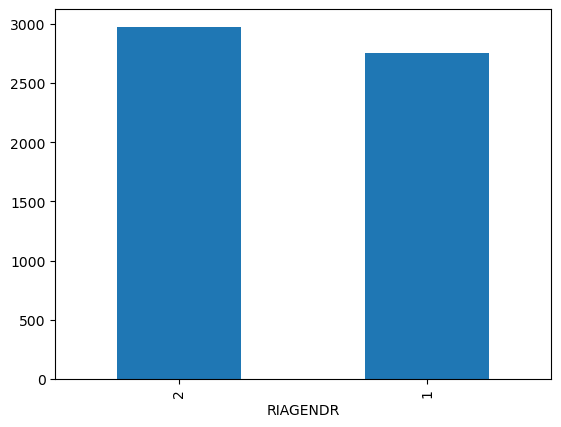

In [6]:
gender.value_counts().plot(kind='bar') # we can make bar graph to visualize count
plt.show()

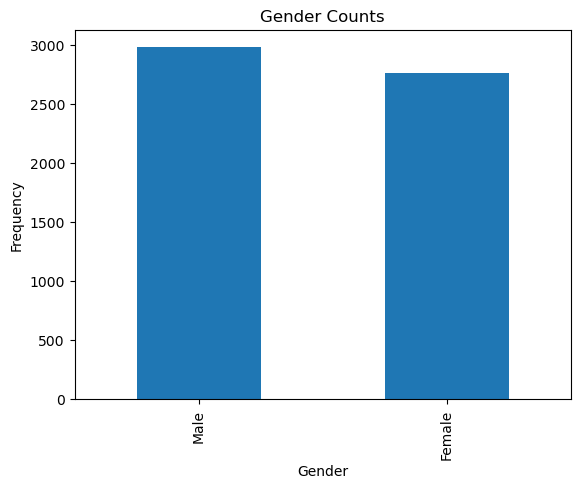

In [8]:
gender.value_counts().plot(kind='bar')
plt.title("Gender Counts")
plt.xticks([0, 1], ['Male', 'Female'])
plt.ylabel("Frequency")
plt.xlabel("Gender")
plt.show()

In [9]:
## now this is better than first one as labeled

In [6]:
sizes = np.array([36, 38, 40, 42, 44, 38, 40, 36, 42, 44, 36, 38, 42, 44, 42, 44, 36, 40, 42, 44, 36, 38, 36, 38, 40])

In [7]:
sizes.mean()

np.float64(39.84)

In [8]:
# we can calculate mode to check which shirt is sold most
from collections import Counter
cnt = Counter()

for size in sizes:
    cnt[size] += 1

cnt.most_common()     # index 0 is the most common ie the mode

[(np.int64(36), 6),
 (np.int64(38), 5),
 (np.int64(42), 5),
 (np.int64(44), 5),
 (np.int64(40), 4)]

##### there is alternative scipy library

In [16]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 487.5 kB/s  0:01:17 eta 0:00:010:00:03


In [17]:
from scipy import stats
stats.mode(sizes)

ModeResult(mode=np.int64(36), count=np.int64(6))

In [18]:
gender.mode() # in pandas

0    2
Name: RIAGENDR, dtype: int64

In [19]:
stats.mode(gender)  # gives frequency also

ModeResult(mode=np.int64(2), count=np.int64(2976))

### More than "one" classes

In [21]:
da['HIQ210'].unique()

array([ 2., nan,  1.,  9.])

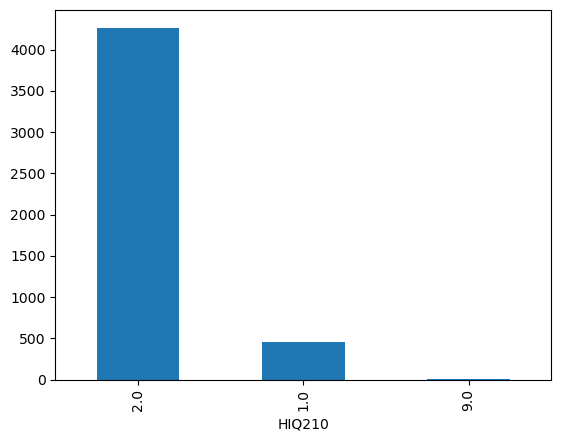

In [23]:
da['HIQ210'].value_counts().plot(kind='bar')
plt.show()

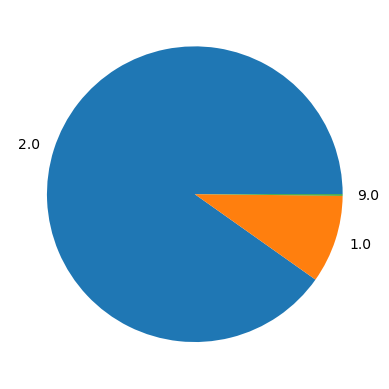

In [24]:
da['HIQ210'].value_counts().plot(kind='pie') # highly not recommended
plt.show()

### studying real valued numbers

In [17]:
wt = da['BMXWT']

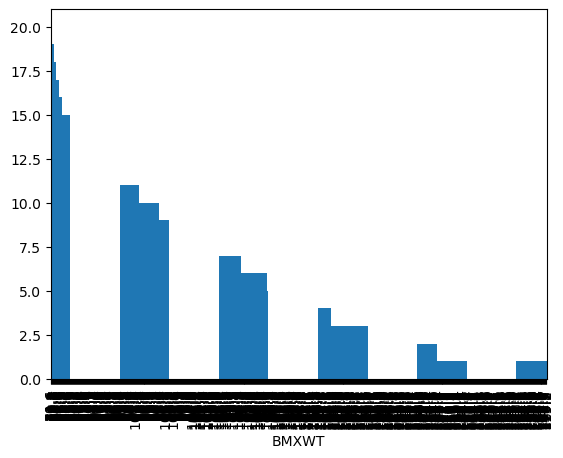

In [27]:
wt.value_counts().plot(kind='bar')  # this does not really work well as it is continuous
plt.show()

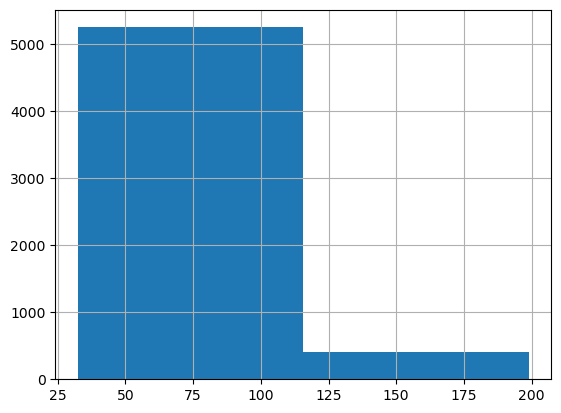

In [30]:
wt.hist(bins=2)
plt.show()

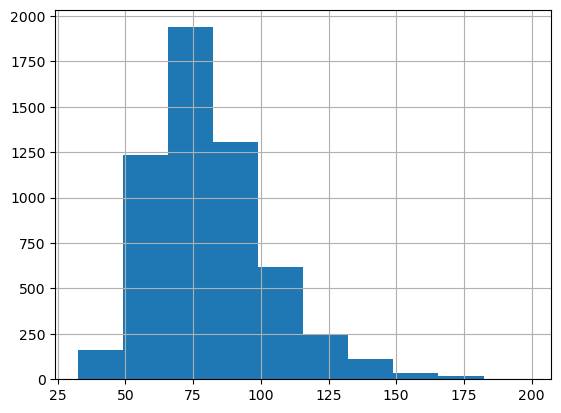

In [32]:
# prev doesn't show well which range has most people 
# we can imporve that by increasing number of bins
wt.hist(bins=10)
plt.show()

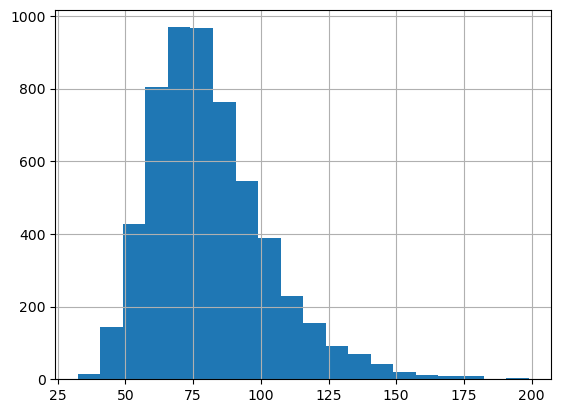

In [33]:
wt.hist(bins=20)
plt.show()

### Custom Matplotlib histogram

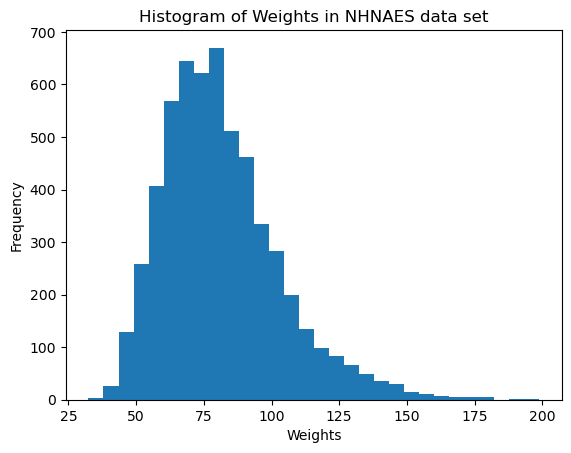

In [34]:
plt.hist(wt, bins=30)
plt.ylabel('Frequency')
plt.xlabel('Weights')
plt.title("Histogram of Weights in NHNAES data set")
plt.show()

### Prettifying and Styling Matplotlib using "Seaborn"

In [35]:
!pip install seaborn

In [33]:
import seaborn as sns
sns.set(color_codes=True)
sns.set_style("white")

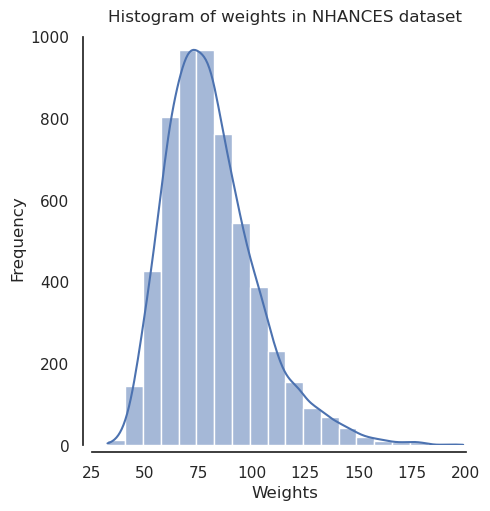

In [40]:
sns.displot(wt, bins=20, kde=True) # kde for trend line
plt.ylabel('Frequency')
plt.xlabel('Weights')
plt.title("Histogram of weights in NHANCES dataset")
sns.despine(offset=5, trim=True)  # move axis away
plt.show()

#### now it is more visually pleasing

### Studying central tendency

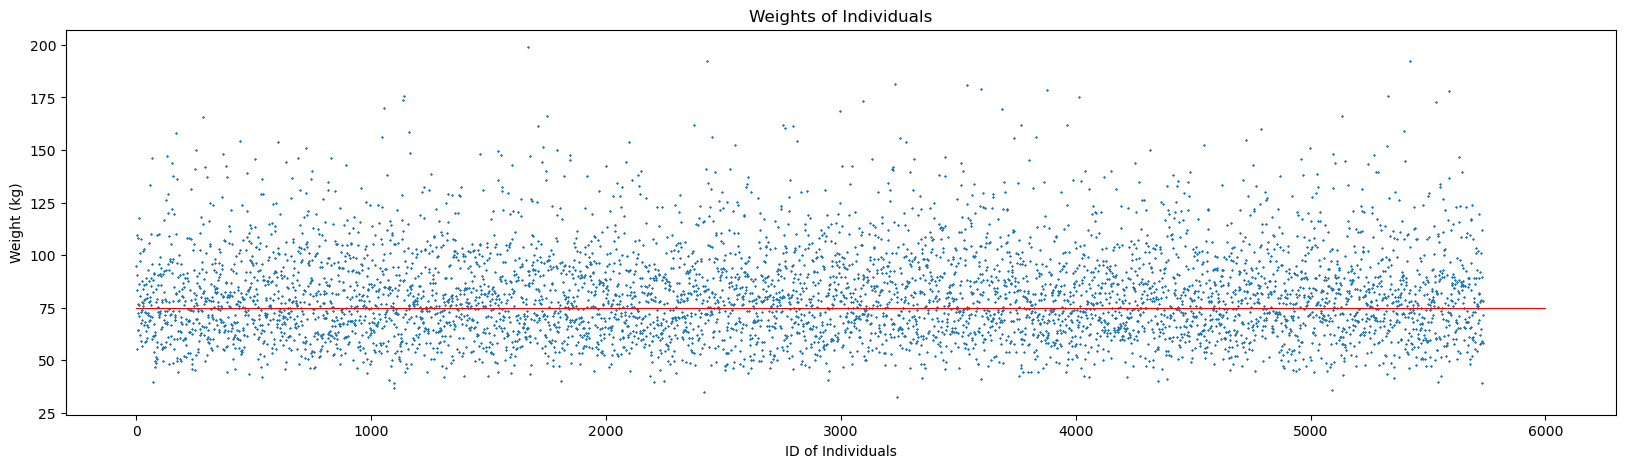

In [10]:
plt.figure(figsize=(20, 5))

x = range(da['BMXWT'].size)
y = da['BMXWT']

plt.scatter(x, y, marker='x', s= 0.5)

plt.title("Weights of Individuals")
plt.xlabel("ID of Individuals")
plt.ylabel("Weight (kg)")

#plot the estime line by self
p1 = (0, 75) # point coordinates
p2 = (6000, 75)
x_c, y_c = zip(p1, p2) # zip x and y co-ordinates
plt.plot(x_c, y_c, color='red', linewidth=0.75)
plt.show()

In [14]:
print(list(zip(p1, p2)))

[(0, 6000), (75, 75)]


In [15]:
# Three lists to zip
subjects = ["Math", "English", "Science"]
grades = [88, 79, 92]
teachers = ["Mr. Smith", "Ms. Johnson", "Mrs. Lee"]

# Zipping three lists together
zipped_info = zip(subjects, grades, teachers)

# Convert to a list to see the result
print(list(zipped_info))

[('Math', 88, 'Mr. Smith'), ('English', 79, 'Ms. Johnson'), ('Science', 92, 'Mrs. Lee')]


In [18]:
## lets see actual mean
wt.mean()

np.float64(81.34267560889516)

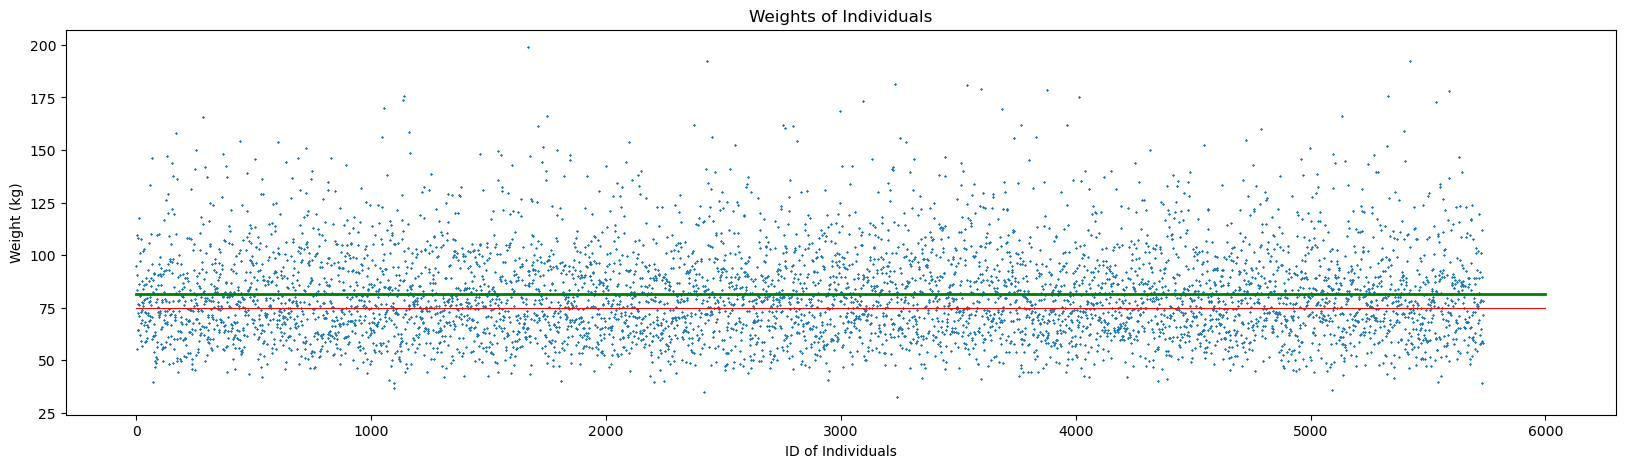

In [19]:
plt.figure(figsize=(20, 5))

x = range(da['BMXWT'].size)
y = da['BMXWT']

plt.scatter(x, y, marker='x', s= 0.5)

plt.title("Weights of Individuals")
plt.xlabel("ID of Individuals")
plt.ylabel("Weight (kg)")

#plot the estime line by self
p1 = (0, 75) # point coordinates
p2 = (6000, 75)
x_c, y_c = zip(p1, p2) # zip x and y co-ordinates
plt.plot(x_c, y_c, color='red', linewidth=0.75)

#plot the actual mean line in green
x_c, y_c = ([0, 6000], [wt.mean(), wt.mean()])
plt.plot(x_c, y_c, color='green', linewidth=2)

plt.show()

###### Arithmetic Mean is effected a lot by outliers.
###### Bur media is simply a cutt between the data 
###### so it is roubust to outliers ie not effected by the outliers.

In [20]:
nums = np.array([3, 4, 9, 17, 18, 20, 22, 23, 29, 32, 39, 43, 42, 42, 51, 97])
np.mean(nums)

np.float64(30.6875)

In [21]:
# if we change 97 to 197 mean become 36 and if remove 97 mean become 26
# lets try median 
np.median(nums)

np.float64(26.0)

In [22]:
# now if we chage 97 to 197 median does not change

### Visualizing Weights data

In [24]:
wt.max()

np.float64(198.9)

In [25]:
wt.min()

np.float64(32.4)

In [26]:
wt.median()

np.float64(78.2)

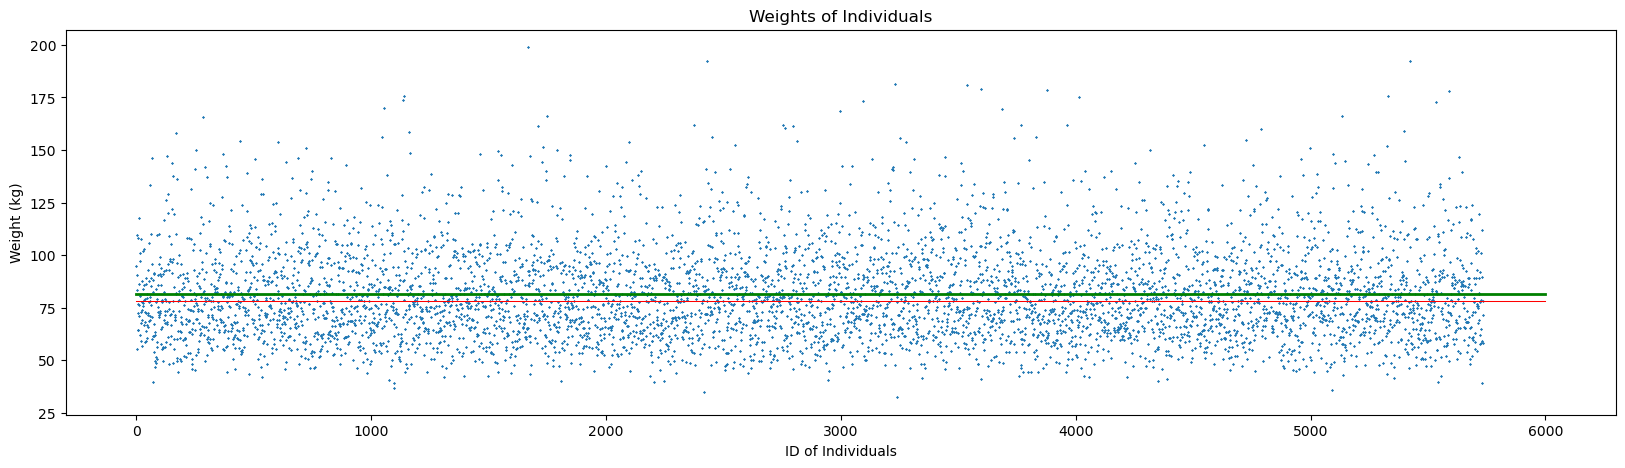

In [29]:
plt.figure(figsize=(20, 5))

x = range(da['BMXWT'].size)
y = da['BMXWT']

plt.scatter(x, y, marker='x', s= 0.5)

plt.title("Weights of Individuals")
plt.xlabel("ID of Individuals")
plt.ylabel("Weight (kg)")

#plot the line for median in red
x_c, y_c = ([0, 6000], [wt.median(), wt.median()])
plt.plot(x_c, y_c, color='red', linewidth=0.75)

#plot the line for mean in green
x_c, y_c = ([0, 6000], [wt.mean(), wt.mean()])
plt.plot(x_c, y_c, color='green', linewidth=2)

plt.show()

## Quartiles and Boxplots

In [30]:
import statistics

In [31]:
statistics.quantiles(nums, n=4) # n is no of quanties to form

[np.float64(17.25), np.float64(26.0), np.float64(42.0)]

In [32]:
statistics.quantiles(wt, n=4)

[43.7, 50.8, 50.1]

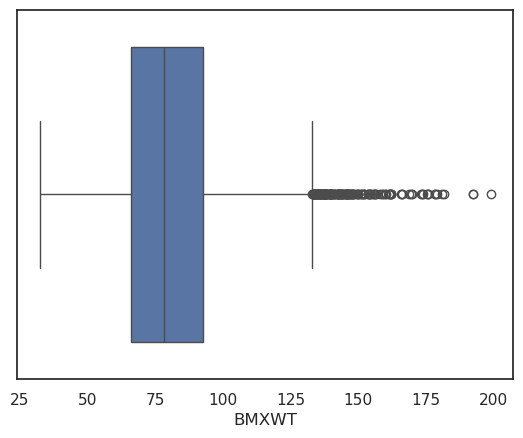

In [34]:
ax = sns.boxplot(x=wt)

In [48]:
#let's seperate the male and female wieghts
male_wt = da.loc[da['RIAGENDR'] == 1, 'BMXWT']
male_wt

0        94.8
1        90.4
2        83.4
6        76.6
8        72.4
        ...  
5726     78.7
5728     89.5
5729     39.2
5731    112.1
5733     78.2
Name: BMXWT, Length: 2759, dtype: float64

In [49]:
male_wt.mean()

np.float64(86.57326222876058)

In [50]:
female_wt = da.loc[da['RIAGENDR'] == 2, 'BMXWT']
female_wt


3       109.8
4        55.2
5        64.4
7        64.5
12       71.2
        ...  
5724     58.2
5727     64.8
5730     59.1
5732     71.7
5734     58.3
Name: BMXWT, Length: 2976, dtype: float64

In [51]:
female_wt.mean()

np.float64(76.51676280963693)

/tmp/ipykernel_99312/24662861.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="RIAGENDR", y="BMXWT", data=da, palette="Set3")


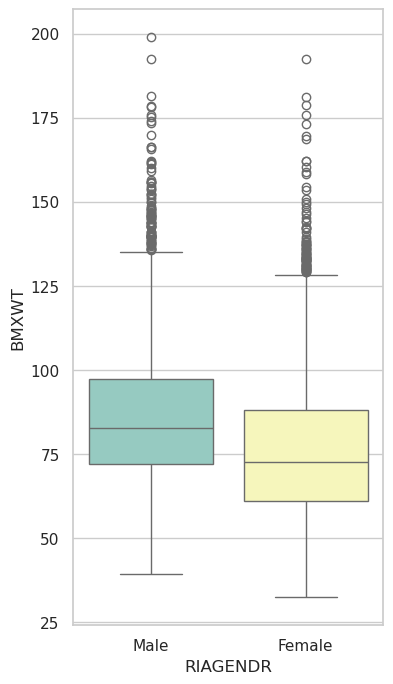

In [52]:
# But there's an easier way
plt.figure(figsize=(4,8))
plt.xticks([0, 1], ['Male', 'Female'])
sns.set_style("whitegrid")

ax = sns.boxplot(x="RIAGENDR", y="BMXWT", data=da, palette="Set3")

/tmp/ipykernel_99312/2211694643.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="HIQ210", y="BMXWT", data=da, palette="Set3")


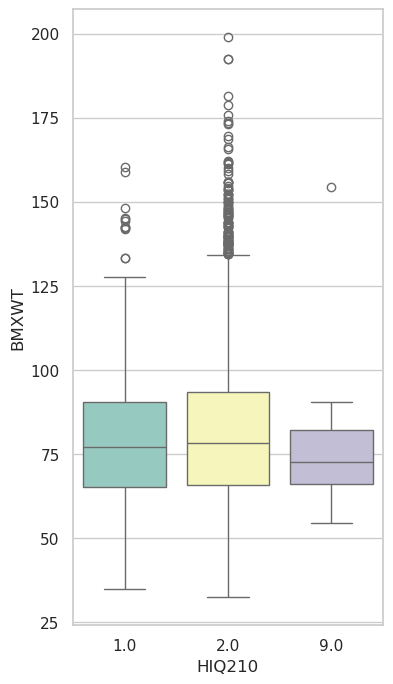

In [53]:
# But there's an easier way
plt.figure(figsize=(4,8))
sns.set_style("whitegrid")

ax = sns.boxplot(x="HIQ210", y="BMXWT", data=da, palette="Set3")